# 1. Aggregation 
This notebook does the following:
- aggregate kNDVI time series per vegetation type
- remove seasonality for these time series
- compute resilience, resistance and recovery from these time series
- aggregate predictor variables per vegetation type as well
- unify in one dataframe

This is done for only one event in this notebook. Te automated process for all events is found in *analysis_execution.py*.



#### Considerations
- for steady state computatuon, i have to limit the selection of events to the ones that are not within 3 years (3*365) of the edges from the tempral coverage of kndvi data -> loss of  more events
- maybe i should not remove seasonality at all from kndiv time series
- do i use mean, median, min or max to aggregate kndvi time series?

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import xarray as xr

# Handling files
import requests
import zipfile
import tempfile
import io
import os
import glob

# Acces APIs
from xcube.core.store import new_data_store

# Plotting  
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Handling dates
import datetime
from datetime import timedelta

# Import own functions
from utils import event_sampling as es
from utils import event_visualization as ev
from utils import event_analysis
#from utils.event_analysis import apply_stl_decomposition # Not yet defined

# Analysis
from statsmodels.tsa.seasonal import STL

import importlib

## 1.1 Load data
- kNDVI
- event summary
- event cube
- land mask
- land cover

### kNDVI array

In [2]:
# Import kNDVI dataset
url = 'https://data.rsc4earth.de/download/EarthSystemDataCube/v3.0.1/esdc-8d-0.25deg-1x720x1440-3.0.1.zarr/'
ds_esdc = xr.open_zarr(url)

# Select kNDVI
kndvi = ds_esdc['kndvi']

### Event summary dataframe

In [3]:
# URL
url_chd_summary = "https://zenodo.org/records/14884254/files/MergedEventStats_landonly_int.csv.zip?download=1"

# Download the ZIP file
response = requests.get(url_chd_summary)
response.raise_for_status()

# Unzip the content
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    csv_filename = z.namelist()[0]
    with z.open(csv_filename) as f:
        df_chd_summary = pd.read_csv(f)

# Create new column 'duration_days' with numeric values
df_chd_summary['duration_days'] = df_chd_summary['duration'].str.extract(r'(\d+)').astype(int)

# Convert start_time and end_time to datetime
df_chd_summary['start_time'] = pd.to_datetime(df_chd_summary['start_time'])
df_chd_summary['end_time'] = pd.to_datetime(df_chd_summary['end_time'])

# Filter dataframe for event duration
df_chd_filtered = df_chd_summary[df_chd_summary['duration_days'] >= 18]

# Filter dataframe for period of ESDC kndvi data (2 year edges)
df_chd_filtered = df_chd_filtered[
    (df_chd_filtered['start_time'].dt.year >= 2002) &
    (df_chd_filtered['start_time'].dt.year <= 2019) &
    (df_chd_filtered['end_time'].dt.year >= 2002) &
    (df_chd_filtered['end_time'].dt.year <= 2019)
]

print(len(df_chd_filtered))

# Show DataFrame 
df_chd_filtered.sort_values('duration_days', ascending=False).head(10)


189


,label,start_time,end_time,longitude_min,longitude_max,latitude_min,latitude_max,t2mmax_mean,t2mmax_min,t2mmax_max,...,compound,land_share,inth,intd30,intd90,intd180,volume,duration,area,duration_days
10,105411,2016-02-27,2016-05-20,92.75,118.25,3.00,23.50,38.429633,29.907460,45.535502,...,100.0,100.0,16248.457214,10882.885354,11231.448425,4240.130612,22975.648359,84 days,273.519623,84
2247,100731,2015-07-14,2015-09-16,286.00,287.50,18.25,18.50,32.880938,29.240437,36.768260,...,100.0,100.0,218.550028,139.169701,181.245710,62.101517,304.527434,65 days,4.685037,65
178,104887,2016-02-09,2016-04-11,281.50,289.25,6.75,11.00,36.907783,22.837075,43.576030,...,100.0,100.0,2804.125332,957.145596,2107.004000,68.015374,3891.942409,63 days,61.776864,63
5813,109935,2017-01-27,2017-03-28,281.50,284.25,-14.75,-9.00,30.171803,27.822229,32.105410,...,100.0,100.0,63.215312,45.751063,38.967732,31.212608,85.665001,61 days,1.404344,61
21,86754,2011-07-15,2011-09-06,257.50,268.50,25.25,38.75,39.917825,29.952395,44.899790,...,100.0,100.0,10715.279400,7707.308031,7458.921376,5892.946581,17479.844032,54 days,323.700815,54
2383,97552,2014-08-15,2014-10-07,237.50,248.25,24.75,38.00,33.195644,27.402290,41.851355,...,100.0,100.0,173.154032,13.869059,76.569025,222.459604,279.819932,54 days,5.181851,54
6754,107867,2016-07-22,2016-09-13,321.75,340.75,65.75,77.50,11.604721,5.434857,19.997050,...,100.0,100.0,41.709392,40.295264,6.090612,0.285918,68.632860,54 days,1.270979,54
3,104409,2016-01-20,2016-03-13,0.00,359.75,-0.25,11.00,37.855397,25.982071,44.140147,...,100.0,100.0,24790.693774,19095.290823,18766.811721,306.037278,38512.666189,54 days,713.197522,54
2,83007,2010-07-02,2010-08-21,4.50,64.50,36.00,65.50,35.294501,21.937143,46.318790,...,100.0,100.0,66906.175092,68960.197766,36294.144024,11858.191820,87107.659248,51 days,1707.993319,51
39,107547,2016-07-02,2016-08-21,55.75,98.00,62.25,74.50,27.641322,12.107263,33.150924,...,100.0,100.0,7851.432595,9672.583045,3667.564724,509.444570,11650.042910,51 days,228.432214,51


### Event cube dataset

In [4]:
# Open zarr dataset
ds_chd_labels = xr.open_zarr('data/temp_zarr_extracted/mergedlabels_ranked_pot0.01_ne0.1_cmp_S1_T3_1950_2023.zarr', consolidated=False)

### Land mask array

In [5]:
# Open with xarray
path_landmask = "data/GLDASp5_landmask_025d.nc4"
ds_landmask = xr.open_dataset(path_landmask)

# Open the right variable as land mask
landmask = ds_landmask['GLDAS_mask']

### Land cover array and translation dataframe
Either use [Land Cover Cube (0.027 degrees)](https://deepesdl.readthedocs.io/en/latest/datasets/LC-1x2025x2025-2-0-0-levels/) or [GLDAS Dominant Vegetation (NOAH3.6, 1 degree)](https://ldas.gsfc.nasa.gov/gldas/vegetation-class-mask).

In [6]:
# Open with xarray
path_veg = 'data/GLDASp5_domveg_NOAH3.6_025d.nc4'
ds_veg = xr.open_dataset(path_veg)

# Open the right variable
vegetation = ds_veg['GLDAS_domveg']

In [7]:
# Open class translation dataframe
df_translation = pd.read_csv("data/GLDA_veg_legend.csv", index_col=0)

## 1.2 Prepare data (from here on process has to be looped over all events)

- create event mask with land mask and label cube
- create event array with kndvi data array and event mask

### Event mask


In [8]:
# Create event area mask 
event_mask_105411 = es.create_event_mask(105411, event_table=df_chd_filtered, labelcube=ds_chd_labels, land_mask=landmask)

### Event array

In [9]:
# Determine event start and end
start_time_value = df_chd_filtered.loc[df_chd_filtered['label'] == 105411, 'start_time'].values[0]
end_time_value = df_chd_filtered.loc[df_chd_filtered['label'] == 105411, 'end_time'].values[0]

In [10]:
# 2 years buffer
buffer = 2 * 365

# Create event array
kndvi_array_105411 = es.create_event_dataarray(kndvi, event_mask_105411, start_date=start_time_value, end_date=end_time_value, time_buffer=buffer)

## 1.3 Aggregate kNDVI time series per land cover type
This aggregation is for the time series, i.e. returns aggregated time series per land cover type.

In [11]:
df_105411_mean_kndvi_ts = event_analysis.aggregate_kndvi_timeseries(kndvi_array_105411, vegetation, event_mask_105411, method='mean')
'''df_105411_median_kndvi_ts = event_analysis.aggregate_kndvi_timeseries(kndvi_array_105411, vegetation, event_mask_105411, method='median')
df_105411_min_kndvi_ts = event_analysis.aggregate_kndvi_timeseries(kndvi_array_105411, vegetation, event_mask_105411, method='min')
df_105411_max_kndvi_ts = event_analysis.aggregate_kndvi_timeseries(kndvi_array_105411, vegetation, event_mask_105411, method='max')'''

"df_105411_median_kndvi_ts = event_analysis.aggregate_kndvi_timeseries(kndvi_array_105411, vegetation, event_mask_105411, method='median')\ndf_105411_min_kndvi_ts = event_analysis.aggregate_kndvi_timeseries(kndvi_array_105411, vegetation, event_mask_105411, method='min')\ndf_105411_max_kndvi_ts = event_analysis.aggregate_kndvi_timeseries(kndvi_array_105411, vegetation, event_mask_105411, method='max')"

#### Visualisation of the aggregation

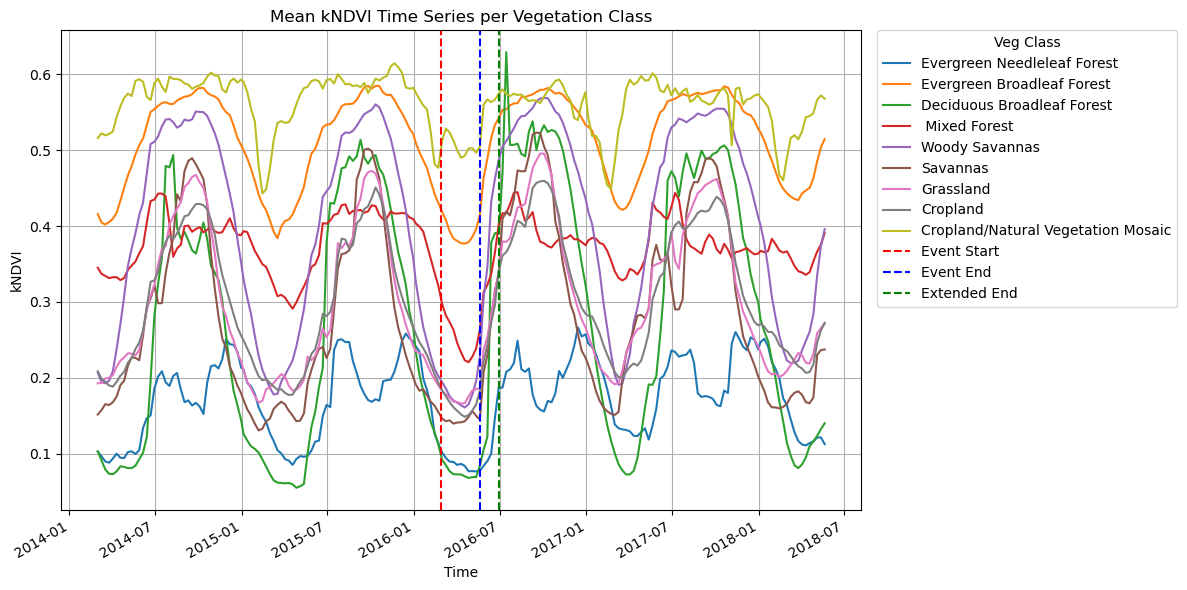

"ev.plot_aggregated_ts(df_105411_median_kndvi_ts, start_time_value, end_time_value, method='Median', df_translation=df_translation)\nev.plot_aggregated_ts(df_105411_min_kndvi_ts, start_time_value, end_time_value, method='Min', df_translation=df_translation)\nev.plot_aggregated_ts(df_105411_max_kndvi_ts, start_time_value, end_time_value, method='Max', df_translation=df_translation)"

In [13]:
ev.plot_aggregated_ts(df_105411_mean_kndvi_ts, start_time_value, end_time_value, method='Mean', df_translation=df_translation)
'''ev.plot_aggregated_ts(df_105411_median_kndvi_ts, start_time_value, end_time_value, method='Median', df_translation=df_translation)
ev.plot_aggregated_ts(df_105411_min_kndvi_ts, start_time_value, end_time_value, method='Min', df_translation=df_translation)
ev.plot_aggregated_ts(df_105411_max_kndvi_ts, start_time_value, end_time_value, method='Max', df_translation=df_translation)'''

# 2. Calculate event statistics

Best hyperparameters found (already internally used by event_analysis.ts_decomposition()):
- inner_iter: 1
- outer_iter: 17
- seasonal: 155
- trend: 49

In [53]:
# Calculate event statistics for deseasonalized data
df_stats_deseasonalized = event_analysis.calculate_event_stats(df_105411_mean_kndvi_ts, start_time_value, end_time_value)
df_stats_deseasonalized.T


,vpre,vdist,vpost,resilience,resistance,recovery,n_days_vdist,anomaly_strength,anomaly_strength_day
1,0.169362,0.102728,0.185994,1.098207,0.606558,-0.523292,91.0,-0.433011,-0.027063
2,0.510465,0.432749,0.523675,1.025878,0.847754,-0.756828,67.0,-0.550917,-0.034432
4,0.252162,0.181436,0.329985,1.308625,0.719525,-0.570976,99.0,-0.580130,-0.036258
5,0.381611,0.253279,0.375676,0.984447,0.663709,-0.541312,67.0,-1.225491,-0.076593
8,0.395310,0.254248,0.422110,1.067795,0.643162,-0.475300,67.0,-0.757038,-0.047315
9,0.271831,0.140614,0.307745,1.132118,0.517284,-0.350152,75.0,-0.778722,-0.048670
10,0.295616,0.202711,0.322197,1.089919,0.685725,-0.566240,83.0,-0.845740,-0.052859
12,0.295974,0.236581,0.319295,1.078793,0.799331,-0.716618,67.0,-0.605916,-0.037870
14,0.568698,0.466278,0.557683,0.980630,0.819904,-0.728500,75.0,-0.388460,-0.024279


## 3. Prepare predictors
This section aims to consolidate all predictor variables into one dataframe. This uncludes the following steps:
- loading of event characteristics (for spatiotempral masking)
- compute number of days affected
- loading of predictor variables (mostly from ESDC)
    - t2m mean, t2m max, t2m min
    - precipitation
    - soil moisture
    - evaporation
    - potential evaporation
    - SPEI
- stack dimensions of masked predictor variables, group by vegetation type
- create dataframe

Later, the target variables from step 2 will be added to this dataframe.

### 3.1 Load variables


In [ ]:
# Load data arrays
t2m = ds_esdc['air_temperature_2m']
t2mmin = ds_esdc['min_air_temperature_2m']
t2mmax = ds_esdc['max_air_temperature_2m']
prec = ds_esdc['precipitation_era5']
soil_moist = ds_esdc['root_moisture']
evap = ds_esdc['evaporation']
evap_pot = ds_esdc['potential_evaporation']

# Create event arrays
t2m_array_105411 = es.create_event_dataarray(d_array = t2m, event_mask = event_mask_105411, start_date=start_time_value, end_date=end_time_value)
t2mmin_array_105411 = es.create_event_dataarray(d_array = t2mmin, event_mask = event_mask_105411, start_date=start_time_value, end_date=end_time_value)
t2mmax_array_105411 = es.create_event_dataarray(d_array = t2mmax, event_mask = event_mask_105411, start_date=start_time_value, end_date=end_time_value)
prec_array_105411 = es.create_event_dataarray(d_array = prec, event_mask = event_mask_105411, estart_date=start_time_value, end_date=end_time_value)
soil_moist_array_105411 = es.create_event_dataarray(d_array = soil_moist, event_mask = event_mask_105411, start_date=start_time_value, end_date=end_time_value)
evap_array_105411 = es.create_event_dataarray(d_array = evap, event_mask = event_mask_105411, estart_date=start_time_value, end_date=end_time_value)
evap_pot_array_105411 = es.create_event_dataarray(d_array = evap_pot, event_mask = event_mask_105411, start_date=start_time_value, end_date=end_time_value)

### 3.2 Compute and aggregate predictors
#### Number of days affected

In [55]:
event_count_105411 = event_analysis.calculate_n_days_affected(start_time_value, end_time_value, event_mask_105411, event_label=105411, ds_label=ds_chd_labels) # Already tailored to specific event

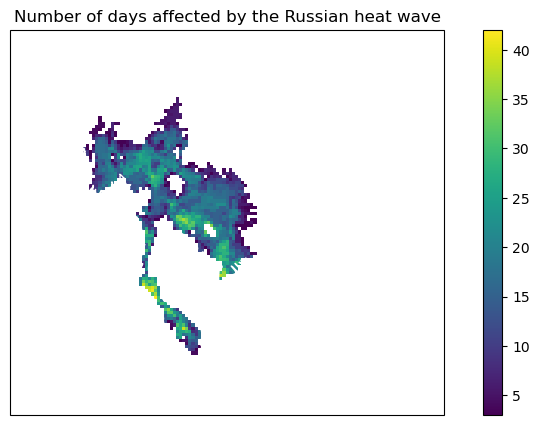

In [56]:
# Plot the event count array
plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
event_count_105411.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis', add_colorbar=True)
ax.set_title("Number of days affected by the Russian heat wave")
ax.coastlines(color='white')
ax.set_extent([88, 123, -2, 28])
plt.show()

### 4. Put together target values and predictors


In [58]:
event_count_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation, 
                                                                event_mask=event_mask_105411, 
                                                                data_array=event_count_105411, 
                                                                method='mean')
t2m_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=t2m_array_105411,
                                                   method='mean')
t2mmin_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=t2mmin_array_105411,
                                                   method='mean')
t2mmax_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=t2mmax_array_105411,
                                                   method='mean')
prec_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=prec_array_105411,
                                                   method='sum',
                                                   area_weighting=True)
soil_moist_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=soil_moist_array_105411,
                                                   method='sum',
                                                   area_weighting=True)
evap_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=evap_array_105411,
                                                   method='sum',
                                                   area_weighting=True)
evap_pot_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=evap_pot_array_105411,
                                                   method='sum',
                                                   area_weighting=True)

# Put series together as dataframe
df_105411 = pd.DataFrame({'n_days': event_count_agg_105411,
                           't2m': t2m_agg_105411,
                           't2mmin': t2mmin_agg_105411,
                           't2mmax': t2mmax_agg_105411,
                           'prec': prec_agg_105411,
                           'soil_moist': soil_moist_agg_105411,
                           'evap': evap_agg_105411,
                           'evap_pot': evap_pot_agg_105411})

# Add event stats to dataframe
df_105411 = df_105411.join(df_stats_deseasonalized.T)

# Add column with event label
df_105411['event_label'] = 105411

# Use vegetation type and event label as multiindex
df_105411 = df_105411.set_index(['event_label', df_105411.index])

# Drop rows with NaN values
df_105411 = df_105411.dropna()

df_105411

n_days        t2m     t2mmin     t2mmax  \
event_label veg_class                                               
105411      1.0        29.997897  29.557693  25.520817  34.984413   
            2.0        14.683297  27.790446  21.158122  36.195617   
            4.0        14.000000  30.718855  23.248274  40.677799   
            5.0        22.998063  29.081753  22.701482  36.906087   
            8.0        12.715875  29.716839  22.487602  38.328789   
            9.0         6.000000  28.984593  20.961587  37.550598   
            10.0       12.577801  29.712650  22.070232  38.149650   
            12.0       16.299947  30.738698  24.054107  38.771194   
            14.0       26.501874  30.612138  23.897044  38.778490   

                                prec    soil_moist           evap  \
event_label veg_class                                               
105411      1.0           108.619068     18.219269      66.592857   
            2.0        102131.954461  15499.235107  154050.646799   
            4.0           147.384407     15.973540      42.959115   
            5.0          1339.638779    237.908392    2272.659649   
            8.0          9366.436542   1668.360501   11565.385971   
            9.0           222.210422     35.451538     238.122716   
            10.0         1599.940661    275.753352    1853.721174   
            12.0        48343.511139   9470.118473   55595.566099   
            14.0          236.985712     45.230905     438.002328   

                            evap_pot      vpre     vdist     vpost  \
event_label veg_class                                                
105411      1.0           328.109334  0.169362  0.102728  0.185994   
            2.0        238921.911156  0.510465  0.432749  0.523675   
            4.0           302.363499  0.252162  0.181436  0.329985   
            5.0          4198.986630  0.381611  0.253279  0.375676   
            8.0         30975.182050  0.395310  0.254248  0.422110   
            9.0           611.618383  0.271831  0.140614  0.307745   
            10.0         4928.420628  0.295616  0.202711  0.322197   
            12.0       175575.590781  0.295974  0.236581  0.319295   
            14.0          615.064440  0.568698  0.466278  0.557683   

                       resilience  resistance  recovery  n_days_vdist  \
event_label veg_class                                                   
105411      1.0          1.098207    0.606558 -0.523292          91.0   
            2.0          1.025878    0.847754 -0.756828          67.0   
            4.0          1.308625    0.719525 -0.570976          99.0   
            5.0          0.984447    0.663709 -0.541312          67.0   
            8.0          1.067795    0.643162 -0.475300          67.0   
            9.0          1.132118    0.517284 -0.350152          75.0   
            10.0         1.089919    0.685725 -0.566240          83.0   
            12.0         1.078793    0.799331 -0.716618          67.0   
            14.0         0.980630    0.819904 -0.728500          75.0   

                       anomaly_strength  anomaly_strength_day  
event_label veg_class                                          
105411      1.0               -0.433011             -0.027063  
            2.0               -0.550917             -0.034432  
            4.0               -0.580130             -0.036258  
            5.0               -1.225491             -0.076593  
            8.0               -0.757038             -0.047315  
            9.0               -0.778722             -0.048670  
            10.0              -0.845740             -0.052859  
            12.0              -0.605916             -0.037870  
            14.0              -0.388460             -0.024279